---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

# Notebook 02 — Limpieza, preprocesamiento, partición y estimación de tamaño


## 1. Importación de librerías

Cargamos las herramientas que usamos para abrir imágenes, limpiar ruido visual, estimar el tamaño aparente de la fruta, balancear el conjunto de entrenamiento, dividir los datos y guardar las salidas que usarán los modelos.


In [1]:
from pathlib import Path
import json
import math
import shutil
import warnings

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42


## 2. Rutas y parámetros

Nosotros definimos las rutas del proyecto y los parámetros principales del preprocesamiento. En este notebook trabajamos con las imágenes propias registradas por el Notebook 01, no con las imágenes descargadas de Kaggle.


In [2]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
RAW_OWN_DIR = PROJECT_ROOT / "data" / "raw" / "propias"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

LABELS_PATH = ANNOTATIONS_DIR / "labels.csv"
LABELS_PROCESSED_PATH = ANNOTATIONS_DIR / "labels_processed.csv"
TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata.csv"
VAL_PATH = ANNOTATIONS_DIR / "val_metadata.csv"
TEST_PATH = ANNOTATIONS_DIR / "test_metadata.csv"
BALANCED_TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata_balanced.csv"
SIZE_THRESHOLDS_PATH = ANNOTATIONS_DIR / "size_thresholds.json"
PREPROCESSING_SUMMARY_PATH = ANNOTATIONS_DIR / "preprocessing_summary.csv"
NOISY_IMAGES_PATH = ANNOTATIONS_DIR / "images_flagged_for_review.csv"

for directory in [ANNOTATIONS_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 128
SIZE_ESTIMATION_IMAGE_SIZE = 192
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
REMOVE_DUPLICATES = True
RESET_PROCESSED_DIR = True
USE_ONLY_OWN_IMAGES = True
BALANCE_TRAIN_SPLIT = True
BALANCE_COLUMNS = ["quality_label"]
MIN_GROUP_SIZE_FOR_SIZE_THRESHOLDS = 12
REFERENCE_DISTANCE_CM = 100.0
DEFAULT_OBJECT_DISTANCE_CM = 100.0
DEFAULT_CAMERA_HORIZONTAL_FOV_DEGREES = 60.0
MIN_SEGMENTATION_CONFIDENCE = 0.10
EXCLUDE_VERY_NOISY_IMAGES = True

VALID_QUALITY_LABELS = ["bad", "regular", "good"]
VALID_SIZE_LABELS = ["small", "medium", "large"]
QUALITY_FOLDER_NAMES = {"bad": "bad", "regular": "regular", "good": "good"}
SIZE_LABELS_ES = {"small": "pequeña", "medium": "mediana", "large": "grande"}
QUALITY_LABELS_ES = {"bad": "mala", "regular": "regular", "good": "buena"}

PRODUCT_SIZE_CM_THRESHOLDS = {
    "apple": (6.5, 8.5),
    "manzana": (6.5, 8.5),
    "lemon": (4.8, 6.3),
    "limon": (4.8, 6.3),
    "lime": (4.5, 6.0),
    "naranja": (6.0, 8.0),
    "orange": (6.0, 8.0),
    "mandarina": (5.0, 7.0),
    "tomate": (5.0, 7.5),
    "banana": (13.0, 18.0),
    "platano": (13.0, 18.0)
}


## 3. Carga de `labels.csv`

El Notebook 01 ya registró las imágenes. Aquí hacemos una verificación por si acaso: confirmamos que el archivo exista, que tenga las columnas mínimas y que todavía existan imágenes para procesar.


In [3]:
if not LABELS_PATH.exists():
    raise FileNotFoundError(f"No encontramos labels.csv en: {LABELS_PATH}")

df = pd.read_csv(LABELS_PATH)
required_columns = ["image_id", "source", "quality_label", "product_type", "relative_path", "file_name", "width", "height"]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en labels.csv: {missing_columns}")

if df.empty:
    raise ValueError("labels.csv no tiene imágenes registradas.")

if "size_label_manual" not in df.columns:
    df["size_label_manual"] = ""

print("Imágenes cargadas:", len(df))
display(df.head())


Imágenes cargadas: 8836


,image_id,source,quality_label,quality_label_es,fruit_type,product_type,size_label_manual,relative_path,file_name,width,height,aspect_ratio,is_square,requires_crop,mode,file_size_kb,blur_score,brightness_mean,brightness_std,skin_tone_ratio,border_std,foreground_ratio_border,image_hash
0,img_22ec7faa3093,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg,IMG-20260603-WA0146.jpg,3024,4032,0.75,False,True,RGB,696.525,81.022385,149.658920,55.720383,0.509583,41.787731,0.876851,22ec7faa30930377d8cfac426a8af9c3
1,img_17007a8abedc,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg,IMG-20260603-WA0148.jpg,3024,4032,0.75,False,True,RGB,904.622,64.758904,140.755127,54.284046,0.654622,55.374147,0.879537,17007a8abedceaa9e71e1780bfee51f5
2,img_c4e96358c5e2,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg,IMG-20260603-WA0150.jpg,3024,4032,0.75,False,True,RGB,845.356,78.428947,140.383789,54.992256,0.708923,43.165718,0.882202,c4e96358c5e2549ad74f27de66b0ad1a
3,img_8ab6ff1acf4e,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg,IMG-20260603-WA0152.jpg,3024,4032,0.75,False,True,RGB,834.975,79.108009,141.237244,54.751041,0.695862,50.041846,0.775899,8ab6ff1acf4ee17e060421ddc280eabe
4,img_1df98c9c28d6,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg,IMG-20260603-WA0154.jpg,3024,4032,0.75,False,True,RGB,801.359,63.087318,129.590408,44.778622,0.658691,43.307025,0.783569,1df98c9c28d60f95afaa3e59483c9f5b


## 4. Normalización mínima

Normalizamos textos, etiquetas y rutas. Además, dejamos por fuera cualquier registro que no pertenezca a nuestras imágenes propias, porque para esta versión del proyecto ya no vamos a usar el material de Kaggle.


In [4]:
df["source"] = df["source"].fillna("own").astype(str).str.lower().str.strip()
df["quality_label"] = df["quality_label"].fillna("").astype(str).str.lower().str.strip()
df["product_type"] = df["product_type"].fillna("unknown").astype(str).str.lower().str.strip()
df["fruit_type"] = df.get("fruit_type", df["product_type"]).fillna(df["product_type"]).astype(str).str.lower().str.strip()
df["size_label_manual"] = df["size_label_manual"].fillna("").astype(str).str.lower().str.strip()
df["relative_path"] = df["relative_path"].fillna("").astype(str).str.replace(chr(92), "/", regex=False).str.strip()

if USE_ONLY_OWN_IMAGES:
    own_source_mask = df["source"].isin(["own", "propias", "propia", "local"])
    own_path_mask = df["relative_path"].str.contains("data/raw/propias", case=False, na=False)
    df = df[own_source_mask | own_path_mask].copy()

manual_size_mask = df["size_label_manual"].isin(VALID_SIZE_LABELS) | (df["size_label_manual"] == "")
df = df[df["quality_label"].isin(VALID_QUALITY_LABELS)].copy()
df = df[manual_size_mask].copy()
df = df.reset_index(drop=True)

if df.empty:
    raise ValueError("Después de normalizar no quedan imágenes propias con calidad válida.")

display(df[["image_id", "source", "quality_label", "product_type", "size_label_manual", "relative_path"]].head())
print("Imágenes propias disponibles:", len(df))


,image_id,source,quality_label,product_type,size_label_manual,relative_path
0,img_22ec7faa3093,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg
1,img_17007a8abedc,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg
2,img_c4e96358c5e2,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg
3,img_8ab6ff1acf4e,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg
4,img_1df98c9c28d6,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg


Imágenes propias disponibles: 8836


## 5. Validación de rutas e imágenes

Antes de limpiar o redimensionar archivos, confirmamos que cada ruta exista y que cada archivo pueda abrirse como imagen. Así evitamos que los modelos fallen más adelante por registros rotos.


In [5]:
def build_image_path(relative_path):
    image_path = Path(str(relative_path).replace(chr(92), "/").strip())
    if image_path.is_absolute():
        return image_path
    return PROJECT_ROOT / image_path


def validate_image(path):
    try:
        with Image.open(path) as image:
            image = ImageOps.exif_transpose(image)
            width, height = image.size
            mode = image.mode
        return True, width, height, mode, ""
    except Exception as error:
        return False, np.nan, np.nan, "", str(error)


df["image_path"] = df["relative_path"].apply(build_image_path)
validation_records = []

for _, row in df.iterrows():
    exists = row["image_path"].exists()
    if exists:
        valid, width, height, mode, error = validate_image(row["image_path"])
    else:
        valid, width, height, mode, error = False, np.nan, np.nan, "", "La ruta no existe"
    validation_records.append({"exists": exists, "valid_image": valid, "validated_width": width, "validated_height": height, "image_mode": mode, "validation_error": error})

validation_df = pd.DataFrame(validation_records)
df = pd.concat([df.reset_index(drop=True), validation_df], axis=1)
invalid_df = df[~df["valid_image"]].copy()
df = df[df["valid_image"]].copy().reset_index(drop=True)

invalid_df.drop(columns=["image_path"], errors="ignore").to_csv(ANNOTATIONS_DIR / "invalid_images_removed.csv", index=False, encoding="utf-8")

print("Imágenes inválidas retiradas:", len(invalid_df))
print("Imágenes válidas:", len(df))


Imágenes inválidas retiradas: 0
Imágenes válidas: 8836


## 6. Retiro de duplicados exactos

Si el Notebook 01 dejó `image_hash`, retiramos copias exactas antes de dividir los datos. Esto evita que una misma foto quede al mismo tiempo en entrenamiento y prueba.


In [6]:
if REMOVE_DUPLICATES and "image_hash" in df.columns:
    duplicated_mask = df.duplicated(subset=["image_hash"], keep="first")
    duplicated_df = df[duplicated_mask].copy()
    df = df[~duplicated_mask].copy().reset_index(drop=True)
elif "image_hash" in df.columns:
    duplicated_df = df[df.duplicated(subset=["image_hash"], keep=False)].copy()
else:
    duplicated_df = pd.DataFrame(columns=df.columns)

duplicated_removed_path = ANNOTATIONS_DIR / "duplicates_removed_before_split.csv"
duplicated_df.drop(columns=["image_path"], errors="ignore").to_csv(duplicated_removed_path, index=False, encoding="utf-8")

print("Duplicados retirados:", len(duplicated_df))
print("Imágenes disponibles:", len(df))


Duplicados retirados: 33
Imágenes disponibles: 8803


## 7. Lectura estándar y segmentación de la fruta

Aquí está el cambio principal de este notebook. Ya no estimamos el tamaño solo por diferencia contra el fondo, porque eso puede confundir una mano, una mesa o un objeto del fondo con la fruta. Ahora combinamos color de fruta, diferencia contra el borde, saturación, limpieza morfológica y descarte parcial de tonos de piel. La idea no es aplicar una sola técnica al 100 %, sino sumar varias señales pequeñas para que el resultado sea más estable.


In [7]:
def read_rgb_image(path):
    image = Image.open(path)
    image = ImageOps.exif_transpose(image)
    return image.convert("RGB")


def pad_image(image, size):
    return ImageOps.pad(image, (size, size), method=Image.Resampling.LANCZOS, color=(255, 255, 255), centering=(0.5, 0.5))


def normalize_product_name(product_type):
    text = str(product_type).lower().strip()
    replacements = {"á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u", "ñ": "n"}
    for source, target in replacements.items():
        text = text.replace(source, target)
    return text


def remove_small_components(mask, min_area):
    mask_u8 = mask.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    clean = np.zeros_like(mask_u8)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 1
    return clean.astype(bool)


def build_skin_mask(rgb_array):
    bgr = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    h, s, v = cv2.split(hsv)
    y, cr, cb = cv2.split(ycrcb)
    skin_ycrcb = (cr >= 133) & (cr <= 178) & (cb >= 77) & (cb <= 135)
    skin_hsv = (h <= 25) & (s >= 20) & (s <= 135) & (v >= 50)
    return skin_ycrcb & skin_hsv


def build_fruit_color_mask(rgb_array, product_type="unknown"):
    product = normalize_product_name(product_type)
    bgr = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    red_mask = (((h <= 12) | (h >= 168)) & (s >= 45) & (v >= 35))
    green_mask = ((h >= 28) & (h <= 95) & (s >= 35) & (v >= 35))
    yellow_mask = ((h >= 12) & (h <= 42) & (s >= 35) & (v >= 45))
    orange_brown_mask = ((h >= 5) & (h <= 30) & (s >= 30) & (v >= 25) & (v <= 235))
    dark_damage_mask = ((s >= 25) & (v >= 20) & (v <= 120))

    if "limon" in product or "lemon" in product or "lime" in product:
        return green_mask | yellow_mask | orange_brown_mask | dark_damage_mask
    if "manzana" in product or "apple" in product:
        return red_mask | green_mask | yellow_mask | orange_brown_mask | dark_damage_mask
    if "naranja" in product or "orange" in product or "mandarina" in product:
        return yellow_mask | orange_brown_mask | dark_damage_mask
    if "tomate" in product or "tomato" in product:
        return red_mask | green_mask | orange_brown_mask | dark_damage_mask
    if "banana" in product or "platano" in product:
        return yellow_mask | green_mask | dark_damage_mask
    return red_mask | green_mask | yellow_mask | orange_brown_mask | dark_damage_mask


def build_background_distance_mask(rgb_array):
    array = rgb_array.astype(np.float32)
    border = np.concatenate([
        array[:6, :, :].reshape(-1, 3),
        array[-6:, :, :].reshape(-1, 3),
        array[:, :6, :].reshape(-1, 3),
        array[:, -6:, :].reshape(-1, 3)
    ], axis=0)
    background = np.median(border, axis=0)
    distance = np.linalg.norm(array - background, axis=2)
    threshold = max(14.0, float(np.percentile(distance, 72)) * 0.70)
    return distance > threshold


def select_best_component(mask, rgb_array, product_type="unknown"):
    h, w = mask.shape
    mask_u8 = mask.astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    fruit_color_mask = build_fruit_color_mask(rgb_array, product_type)
    best_label = None
    best_score = -np.inf
    best_payload = None

    for label in range(1, num_labels):
        x = int(stats[label, cv2.CC_STAT_LEFT])
        y = int(stats[label, cv2.CC_STAT_TOP])
        width = int(stats[label, cv2.CC_STAT_WIDTH])
        height = int(stats[label, cv2.CC_STAT_HEIGHT])
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < h * w * 0.004 or area > h * w * 0.78:
            continue

        component = labels == label
        component_area_ratio = area / (h * w)
        color_ratio = float(fruit_color_mask[component].mean()) if area > 0 else 0.0
        center_x, center_y = centroids[label]
        center_distance = math.sqrt(((center_x - w / 2) / w) ** 2 + ((center_y - h / 2) / h) ** 2)
        border_touch = int(x <= 1 or y <= 1 or x + width >= w - 1 or y + height >= h - 1)
        contours, _ = cv2.findContours(component.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        perimeter = cv2.arcLength(contours[0], True) if contours else 0.0
        circularity = float(4 * math.pi * area / (perimeter ** 2)) if perimeter > 0 else 0.0
        score = (component_area_ratio * 3.0) + (color_ratio * 1.5) + (circularity * 0.7) - (center_distance * 1.2) - (border_touch * 1.0)

        if score > best_score:
            best_score = score
            best_label = label
            best_payload = {"x": x, "y": y, "width": width, "height": height, "area": area, "color_ratio": color_ratio, "circularity": circularity, "center_distance": center_distance, "border_touch": border_touch}

    if best_label is None:
        return np.zeros_like(mask, dtype=bool), None

    return labels == best_label, best_payload


def segment_fruit(rgb_array, product_type="unknown"):
    bgr = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    _, saturation, value = cv2.split(hsv)
    fruit_color_mask = build_fruit_color_mask(rgb_array, product_type)
    background_mask = build_background_distance_mask(rgb_array)
    skin_mask = build_skin_mask(rgb_array)
    saturation_mask = (saturation >= 38) & (value >= 30)
    candidate = (fruit_color_mask | (background_mask & saturation_mask)) & (~skin_mask)
    candidate = remove_small_components(candidate, int(rgb_array.shape[0] * rgb_array.shape[1] * 0.0025))
    kernel = np.ones((5, 5), np.uint8)
    candidate_u8 = candidate.astype(np.uint8) * 255
    candidate_u8 = cv2.morphologyEx(candidate_u8, cv2.MORPH_CLOSE, kernel, iterations=2)
    candidate_u8 = cv2.morphologyEx(candidate_u8, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    candidate = candidate_u8 > 0
    selected_mask, payload = select_best_component(candidate, rgb_array, product_type)
    return selected_mask, skin_mask, fruit_color_mask, payload


## 8. Cálculo de tamaño, ruido y confianza

Calculamos variables geométricas de la fruta segmentada. También guardamos señales de ruido: cuánto tono de piel aparece, qué tan confiable fue la segmentación, si el objeto toca demasiado el borde y si la imagen tiene poca nitidez. Estas variables ayudan a decidir qué imágenes conviene revisar o excluir.


,image_id,quality_label,product_type,size_label_manual,object_area_ratio,normalized_diameter,estimated_diameter_cm,segmentation_confidence,review_reason
0,img_22ec7faa3093,bad,apple,,0.199436,0.524678,60.584602,0.919343,posible_mano_visible
1,img_17007a8abedc,bad,apple,,0.202610,0.523611,60.461354,0.960042,posible_mano_visible
2,img_c4e96358c5e2,bad,apple,,0.242594,0.570930,65.925322,0.935271,posible_mano_visible
3,img_8ab6ff1acf4e,bad,apple,,0.208903,0.581560,67.152803,0.908573,posible_mano_visible
4,img_1df98c9c28d6,bad,apple,,0.161377,0.524814,60.600264,0.825413,posible_mano_visible


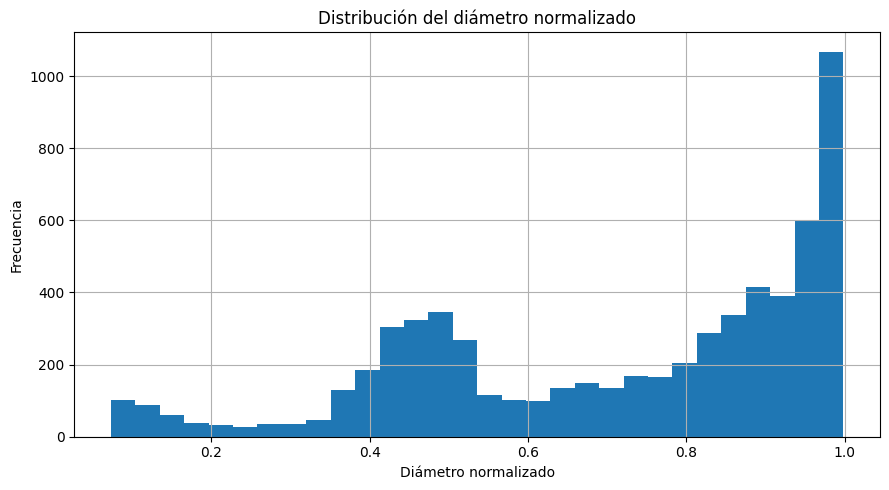

In [8]:
def estimate_distance_cm(row):
    for column in ["distance_cm", "capture_distance_cm", "object_distance_cm"]:
        if column in row.index and pd.notna(row[column]):
            try:
                value = float(row[column])
                if value > 0:
                    return value
            except Exception:
                pass
    return DEFAULT_OBJECT_DISTANCE_CM


def estimate_diameter_cm(diameter_px, image_width_px, distance_cm, camera_fov_degrees=DEFAULT_CAMERA_HORIZONTAL_FOV_DEGREES):
    if pd.isna(diameter_px) or image_width_px <= 0 or distance_cm <= 0:
        return np.nan
    scene_width_cm = 2.0 * distance_cm * math.tan(math.radians(camera_fov_degrees) / 2.0)
    cm_per_pixel = scene_width_cm / image_width_px
    return float(diameter_px * cm_per_pixel)


def estimate_size_features(path, product_type="unknown", distance_cm=DEFAULT_OBJECT_DISTANCE_CM, image_size=SIZE_ESTIMATION_IMAGE_SIZE):
    image = read_rgb_image(path)
    original_width, original_height = image.size
    working_image = pad_image(image, image_size)
    rgb_array = np.asarray(working_image).astype(np.uint8)
    gray = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2GRAY)
    blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    selected_mask, skin_mask, fruit_color_mask, payload = segment_fruit(rgb_array, product_type)
    h, w = selected_mask.shape
    skin_noise_ratio = float(skin_mask.mean())

    if payload is None or selected_mask.sum() == 0:
        diameter_px_normalized_base = np.nan
        normalized_diameter = np.nan
        estimated_diameter_px_original = np.nan
        estimated_diameter_cm_at_distance = np.nan
        return {
            "object_area_ratio": 0.0,
            "bbox_width_ratio": 0.0,
            "bbox_height_ratio": 0.0,
            "bbox_area_ratio": 0.0,
            "diameter_px_normalized_base": diameter_px_normalized_base,
            "normalized_diameter": normalized_diameter,
            "estimated_diameter_px_original": estimated_diameter_px_original,
            "estimated_distance_cm": distance_cm,
            "estimated_diameter_cm": estimated_diameter_cm_at_distance,
            "skin_noise_ratio": skin_noise_ratio,
            "fruit_color_ratio": 0.0,
            "segmentation_confidence": 0.0,
            "blur_score": blur_score,
            "touches_border": 1,
            "needs_review": True,
            "review_reason": "no_detectamos_fruta"
        }

    area = float(payload["area"])
    x = payload["x"]
    y = payload["y"]
    bbox_width = payload["width"]
    bbox_height = payload["height"]
    object_area_ratio = area / (h * w)
    bbox_width_ratio = bbox_width / w
    bbox_height_ratio = bbox_height / h
    bbox_area_ratio = (bbox_width * bbox_height) / (h * w)
    equivalent_diameter = 2.0 * math.sqrt(area / math.pi)
    bbox_diameter = max(bbox_width, bbox_height)
    diameter_px_normalized_base = float(0.55 * bbox_diameter + 0.45 * equivalent_diameter)
    normalized_diameter = float(diameter_px_normalized_base / image_size)
    estimated_diameter_px_original = float(normalized_diameter * max(original_width, original_height))
    estimated_diameter_cm_at_distance = estimate_diameter_cm(estimated_diameter_px_original, max(original_width, original_height), distance_cm)
    segmentation_confidence = float(max(0.0, min(1.0, payload["color_ratio"] * 0.45 + min(object_area_ratio / 0.20, 1.0) * 0.35 + payload["circularity"] * 0.20 - payload["border_touch"] * 0.20)))
    review_reasons = []

    if segmentation_confidence < MIN_SEGMENTATION_CONFIDENCE:
        review_reasons.append("baja_confianza_segmentacion")
    if skin_noise_ratio > 0.20:
        review_reasons.append("posible_mano_visible")
    if object_area_ratio < 0.012:
        review_reasons.append("fruta_muy_pequena_o_lejana")
    if object_area_ratio > 0.70:
        review_reasons.append("objeto_ocupa_casi_toda_la_imagen")
    if payload["border_touch"] == 1:
        review_reasons.append("objeto_toca_borde")
    if blur_score < 25:
        review_reasons.append("imagen_poco_nitida")

    return {
        "object_area_ratio": object_area_ratio,
        "bbox_width_ratio": bbox_width_ratio,
        "bbox_height_ratio": bbox_height_ratio,
        "bbox_area_ratio": bbox_area_ratio,
        "diameter_px_normalized_base": diameter_px_normalized_base,
        "normalized_diameter": normalized_diameter,
        "estimated_diameter_px_original": estimated_diameter_px_original,
        "estimated_distance_cm": distance_cm,
        "estimated_diameter_cm": estimated_diameter_cm_at_distance,
        "skin_noise_ratio": skin_noise_ratio,
        "fruit_color_ratio": float(payload["color_ratio"]),
        "segmentation_confidence": segmentation_confidence,
        "blur_score": blur_score,
        "touches_border": int(payload["border_touch"]),
        "needs_review": len(review_reasons) > 0,
        "review_reason": ";".join(review_reasons)
    }


size_feature_records = []

for _, row in df.iterrows():
    distance_cm = estimate_distance_cm(row)
    size_feature_records.append(estimate_size_features(row["image_path"], row["product_type"], distance_cm))

size_features_df = pd.DataFrame(size_feature_records)
df = pd.concat([df.reset_index(drop=True), size_features_df], axis=1)
size_feature_columns = ["object_area_ratio", "bbox_width_ratio", "bbox_height_ratio", "bbox_area_ratio", "diameter_px_normalized_base", "normalized_diameter", "estimated_diameter_cm", "skin_noise_ratio", "segmentation_confidence", "blur_score"]
size_features_path = TABLES_DIR / "08_size_features_summary.csv"
df[size_feature_columns].describe().T.to_csv(size_features_path, encoding="utf-8")

display(df[["image_id", "quality_label", "product_type", "size_label_manual", "object_area_ratio", "normalized_diameter", "estimated_diameter_cm", "segmentation_confidence", "review_reason"]].head())

ax = df["normalized_diameter"].dropna().plot(kind="hist", bins=30)
ax.set_title("Distribución del diámetro normalizado")
ax.set_xlabel("Diámetro normalizado")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_normalized_diameter_distribution.png", dpi=160)
plt.show()


## 9. Revisión y retiro de imágenes muy ruidosas

No retiramos una imagen solo porque sea difícil. Primero la marcamos para revisión. Luego, si la segmentación prácticamente no encontró fruta o la confianza fue demasiado baja, la retiramos del conjunto que se usará para entrenar. El listado queda guardado para justificar la decisión.


In [9]:
noisy_df = df[df["needs_review"]].copy()
noisy_df.drop(columns=["image_path"], errors="ignore").to_csv(NOISY_IMAGES_PATH, index=False, encoding="utf-8")

if EXCLUDE_VERY_NOISY_IMAGES:
    training_usable_mask = (df["segmentation_confidence"] >= MIN_SEGMENTATION_CONFIDENCE) & df["normalized_diameter"].notna() & (df["object_area_ratio"] >= 0.008) & (df["object_area_ratio"] <= 0.78)
    excluded_noise_df = df[~training_usable_mask].copy()
    df = df[training_usable_mask].copy().reset_index(drop=True)
else:
    excluded_noise_df = pd.DataFrame(columns=df.columns)

excluded_noise_df.drop(columns=["image_path"], errors="ignore").to_csv(ANNOTATIONS_DIR / "images_excluded_by_noise.csv", index=False, encoding="utf-8")

print("Imágenes marcadas para revisión:", len(noisy_df))
print("Imágenes excluidas por ruido extremo:", len(excluded_noise_df))
print("Imágenes que continúan:", len(df))


Imágenes marcadas para revisión: 7505
Imágenes excluidas por ruido extremo: 2562
Imágenes que continúan: 6241


## 10. Etiqueta final de tamaño

Respetamos primero la etiqueta manual si existe. Si no existe, usamos centímetros aproximados cuando hay distancia de captura. Si tampoco tenemos distancia real, usamos umbrales por producto calculados con el diámetro normalizado. Así evitamos depender solamente de qué tan cerca o lejos se tomó una foto.


In [10]:
def quantile_thresholds(values):
    valid_values = pd.Series(values).dropna()
    if len(valid_values) < 3 or valid_values.nunique() < 3:
        return None
    return float(valid_values.quantile(1 / 3)), float(valid_values.quantile(2 / 3))


def label_from_thresholds(value, thresholds):
    if thresholds is None or pd.isna(value):
        return "medium"
    q1, q2 = thresholds
    if value <= q1:
        return "small"
    if value <= q2:
        return "medium"
    return "large"


def label_from_cm(value_cm, product_type="unknown"):
    product = normalize_product_name(product_type)
    thresholds = None
    for key, values in PRODUCT_SIZE_CM_THRESHOLDS.items():
        if key in product:
            thresholds = values
            break
    if thresholds is None or pd.isna(value_cm):
        return None
    return label_from_thresholds(value_cm, thresholds)


def has_real_distance(row):
    for column in ["distance_cm", "capture_distance_cm", "object_distance_cm"]:
        if column in row.index and pd.notna(row[column]):
            try:
                if float(row[column]) > 0:
                    return True
            except Exception:
                pass
    return False


global_thresholds = quantile_thresholds(df["normalized_diameter"])
product_thresholds = {}

for product_type, group in df.groupby("product_type"):
    thresholds = quantile_thresholds(group["normalized_diameter"])
    if thresholds is not None and len(group) >= MIN_GROUP_SIZE_FOR_SIZE_THRESHOLDS:
        product_thresholds[product_type] = thresholds

size_labels = []
size_sources = []

for _, row in df.iterrows():
    manual_label = row["size_label_manual"]
    cm_label = label_from_cm(row["estimated_diameter_cm"], row["product_type"]) if has_real_distance(row) else None

    if manual_label in VALID_SIZE_LABELS:
        size_labels.append(manual_label)
        size_sources.append("manual")
    elif cm_label in VALID_SIZE_LABELS:
        size_labels.append(cm_label)
        size_sources.append("estimated_cm")
    else:
        thresholds = product_thresholds.get(row["product_type"], global_thresholds)
        size_labels.append(label_from_thresholds(row["normalized_diameter"], thresholds))
        size_sources.append("product_quantile" if row["product_type"] in product_thresholds else "global_quantile")

df["size_label"] = size_labels
df["size_label_source"] = size_sources
df["size_label_es"] = df["size_label"].map(SIZE_LABELS_ES)
df["quality_label_es"] = df["quality_label"].map(QUALITY_LABELS_ES)

threshold_payload = {
    "global": None if global_thresholds is None else {"q1": global_thresholds[0], "q2": global_thresholds[1]},
    "by_product": {key: {"q1": value[0], "q2": value[1]} for key, value in product_thresholds.items()},
    "product_size_cm_thresholds": {key: {"small_medium_cm": value[0], "medium_large_cm": value[1]} for key, value in PRODUCT_SIZE_CM_THRESHOLDS.items()},
    "reference_distance_cm": REFERENCE_DISTANCE_CM,
    "default_object_distance_cm": DEFAULT_OBJECT_DISTANCE_CM,
    "camera_horizontal_fov_degrees": DEFAULT_CAMERA_HORIZONTAL_FOV_DEGREES
}

SIZE_THRESHOLDS_PATH.write_text(json.dumps(threshold_payload, indent=4, ensure_ascii=False), encoding="utf-8")

display(df[["image_id", "product_type", "size_label", "size_label_source", "normalized_diameter", "estimated_diameter_cm"]].head())
display(pd.crosstab(df["product_type"], df["size_label"]))


,image_id,product_type,size_label,size_label_source,normalized_diameter,estimated_diameter_cm
0,img_22ec7faa3093,apple,medium,product_quantile,0.524678,60.584602
1,img_17007a8abedc,apple,medium,product_quantile,0.523611,60.461354
2,img_c4e96358c5e2,apple,medium,product_quantile,0.570930,65.925322
3,img_8ab6ff1acf4e,apple,medium,product_quantile,0.581560,67.152803
4,img_1df98c9c28d6,apple,medium,product_quantile,0.524814,60.600264


size_label,large,medium,small
product_type,,,
apple,324,323,324
banana,370,370,371
guava,334,335,335
lime,287,292,290
orange,246,246,246
pomegranate,516,516,516


## 11. Revisión mínima antes de particionar

Comprobamos que sigan existiendo suficientes imágenes y que haya al menos dos clases de calidad. También revisamos la distribución de tamaño porque esa salida alimenta el siguiente notebook.


In [11]:
df = df[df["quality_label"].isin(VALID_QUALITY_LABELS)].copy()
df = df[df["size_label"].isin(VALID_SIZE_LABELS)].copy()
df = df.reset_index(drop=True)

if len(df) < 5:
    raise ValueError("No hay suficientes imágenes válidas para crear train, validation y test.")

if df["quality_label"].nunique() < 2:
    raise ValueError("Se necesitan al menos dos clases de calidad para entrenar y evaluar modelos.")

quality_counts = df["quality_label"].value_counts().reindex(VALID_QUALITY_LABELS, fill_value=0)
size_counts = df["size_label"].value_counts().reindex(VALID_SIZE_LABELS, fill_value=0)
quality_size_counts = pd.crosstab(df["quality_label"], df["size_label"]).reindex(index=VALID_QUALITY_LABELS, columns=VALID_SIZE_LABELS, fill_value=0)

display(pd.DataFrame({"quality_count": quality_counts}))
display(pd.DataFrame({"size_count": size_counts}))
display(quality_size_counts)


,quality_count
quality_label,
bad,1030
regular,3518
good,1693


,size_count
size_label,
small,2082
medium,2082
large,2077


size_label,small,medium,large
quality_label,,,
bad,345,461,224
regular,676,1161,1681
good,1061,460,172


## 12. Partición `train`, `val` y `test`

Dividimos los datos intentando estratificar por calidad y tamaño. Si alguna combinación queda con pocos ejemplos, bajamos a calidad; si tampoco es viable, dividimos sin estratificación para no romper el flujo.


In [12]:
def stratify_series(data):
    combined = data["quality_label"].astype(str) + "_" + data["size_label"].astype(str)
    combined_counts = combined.value_counts()
    if len(combined_counts) > 1 and combined_counts.min() >= 2:
        return combined, "quality_size"

    quality = data["quality_label"].astype(str)
    quality_counts_local = quality.value_counts()
    if len(quality_counts_local) > 1 and quality_counts_local.min() >= 2:
        return quality, "quality"

    return None, "none"


def safe_train_test_split(data, test_size):
    stratify_values, stratify_name = stratify_series(data)
    try:
        left, right = train_test_split(data, test_size=test_size, random_state=RANDOM_STATE, stratify=stratify_values)
    except ValueError:
        left, right = train_test_split(data, test_size=test_size, random_state=RANDOM_STATE, stratify=None)
        stratify_name = "none"
    return left, right, stratify_name


temp_ratio = VAL_RATIO + TEST_RATIO
train_df, temp_df, first_stratify = safe_train_test_split(df, temp_ratio)
second_test_size = TEST_RATIO / temp_ratio
val_df, test_df, second_stratify = safe_train_test_split(temp_df, second_test_size)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df = df.sort_values(["split", "quality_label", "size_label", "product_type", "file_name"]).reset_index(drop=True)

print("Estratificación primer corte:", first_stratify)
print("Estratificación segundo corte:", second_stratify)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Estratificación primer corte: quality_size
Estratificación segundo corte: quality_size
Train: 3744 Val: 1248 Test: 1249


## 13. Balance del conjunto de entrenamiento

El desbalance se maneja solo en entrenamiento. Validación y prueba se conservan como están para evaluar con una distribución más realista. Guardamos dos salidas: `train_metadata.csv` con la partición original y `train_metadata_balanced.csv` con una versión balanceada para entrenamientos que lo requieran.


In [13]:
def balance_dataframe(data, columns, random_state=RANDOM_STATE):
    if data.empty:
        return data.copy(), pd.DataFrame()
    grouped = data.groupby(columns, dropna=False)
    counts = grouped.size()
    if counts.empty or len(counts) <= 1:
        return data.copy(), counts.reset_index(name="count")
    target_count = int(counts.min())
    balanced_parts = []
    for _, group in grouped:
        if len(group) > target_count:
            balanced_parts.append(group.sample(target_count, random_state=random_state))
        else:
            balanced_parts.append(group.copy())
    balanced = pd.concat(balanced_parts, ignore_index=True)
    balanced = balanced.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return balanced, counts.reset_index(name="count")


train_original_df = df[df["split"] == "train"].copy().reset_index(drop=True)
if BALANCE_TRAIN_SPLIT:
    train_balanced_df, train_balance_before = balance_dataframe(train_original_df, BALANCE_COLUMNS)
else:
    train_balanced_df = train_original_df.copy()
    train_balance_before = train_original_df.groupby(BALANCE_COLUMNS, dropna=False).size().reset_index(name="count")

train_balance_after = train_balanced_df.groupby(BALANCE_COLUMNS, dropna=False).size().reset_index(name="count")
train_balance_before.to_csv(TABLES_DIR / "09_train_balance_before.csv", index=False, encoding="utf-8")
train_balance_after.to_csv(TABLES_DIR / "10_train_balance_after.csv", index=False, encoding="utf-8")

display(train_balance_before)
display(train_balance_after)
print("Train original:", len(train_original_df))
print("Train balanceado:", len(train_balanced_df))


,quality_label,count
0,bad,618
1,good,1016
2,regular,2110


,quality_label,count
0,bad,618
1,good,618
2,regular,618


Train original: 3744
Train balanceado: 1854


## 14. Guardado de imágenes procesadas

Guardamos las imágenes cuadradas, en RGB y redimensionadas a 128 x 128. La carpeta queda organizada por partición y calidad para que el Notebook 03 pueda leerlas sin cambiar la lógica principal.


In [14]:
def prepare_processed_directories():
    if RESET_PROCESSED_DIR and PROCESSED_DIR.exists():
        shutil.rmtree(PROCESSED_DIR)

    for split_name in ["train", "val", "test"]:
        for quality_label in VALID_QUALITY_LABELS:
            (PROCESSED_DIR / split_name / QUALITY_FOLDER_NAMES[quality_label]).mkdir(parents=True, exist_ok=True)


def to_project_relative_path(path):
    return path.relative_to(PROJECT_ROOT).as_posix()


def save_processed_image(row):
    image = read_rgb_image(row["image_path"])
    processed_image = pad_image(image, IMAGE_SIZE)
    output_name = f"{row['image_id']}_{row['quality_label']}_{row['size_label']}.jpg"
    output_path = PROCESSED_DIR / row["split"] / QUALITY_FOLDER_NAMES[row["quality_label"]] / output_name
    processed_image.save(output_path, format="JPEG", quality=95)
    return to_project_relative_path(output_path)


prepare_processed_directories()
df["processed_relative_path"] = [save_processed_image(row) for _, row in df.iterrows()]

print("Imágenes procesadas guardadas:", len(df))
display(df[["image_id", "split", "quality_label", "size_label", "processed_relative_path"]].head())


Imágenes procesadas guardadas: 6241


,image_id,split,quality_label,size_label,processed_relative_path
0,img_c4437d0fe2dd,test,bad,large,data/processed/test/bad/img_c4437d0fe2dd_bad_large.jpg
1,img_01b1c448e882,test,bad,large,data/processed/test/bad/img_01b1c448e882_bad_large.jpg
2,img_62a613d1d6ca,test,bad,large,data/processed/test/bad/img_62a613d1d6ca_bad_large.jpg
3,img_5e2c43b4a3f0,test,bad,large,data/processed/test/bad/img_5e2c43b4a3f0_bad_large.jpg
4,img_53d463eaf16f,test,bad,large,data/processed/test/bad/img_53d463eaf16f_bad_large.jpg


## 15. Guardado de metadatos procesados

Guardamos los CSV finales que usarán los notebooks de modelos clásicos y redes neuronales. Además, dejamos una versión balanceada del entrenamiento para comparar resultados sin alterar validación ni prueba.


In [15]:
df_export = df.drop(columns=["image_path"], errors="ignore").copy()
train_export = df_export[df_export["split"] == "train"].copy().reset_index(drop=True)
val_export = df_export[df_export["split"] == "val"].copy().reset_index(drop=True)
test_export = df_export[df_export["split"] == "test"].copy().reset_index(drop=True)
train_balanced_export = train_export[train_export["image_id"].isin(train_balanced_df["image_id"])].copy().reset_index(drop=True)

df_export.to_csv(LABELS_PROCESSED_PATH, index=False, encoding="utf-8")
train_export.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
val_export.to_csv(VAL_PATH, index=False, encoding="utf-8")
test_export.to_csv(TEST_PATH, index=False, encoding="utf-8")
train_balanced_export.to_csv(BALANCED_TRAIN_PATH, index=False, encoding="utf-8")

print("labels_processed:", LABELS_PROCESSED_PATH)
print("train:", TRAIN_PATH)
print("train balanceado:", BALANCED_TRAIN_PATH)
print("val:", VAL_PATH)
print("test:", TEST_PATH)


labels_processed: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\labels_processed.csv
train: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\train_metadata.csv
train balanceado: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\train_metadata_balanced.csv
val: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\val_metadata.csv
test: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\test_metadata.csv


## 16. Distribución final

Estas tablas no repiten el EDA. Solo verifican que la partición final conserve clases de calidad, tamaño y producto de forma razonable.


quality_label,bad,regular,good
split,,,
train,618,2110,1016
val,206,703,339
test,206,705,338


size_label,small,medium,large
split,,,
train,1250,1249,1245
val,416,416,416
test,416,417,416


,train_balanced
quality_label,
bad,618
regular,618
good,618


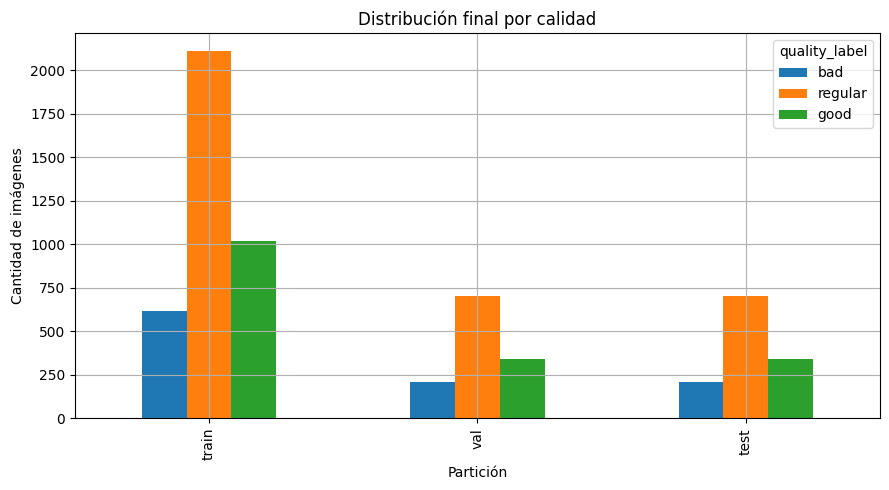

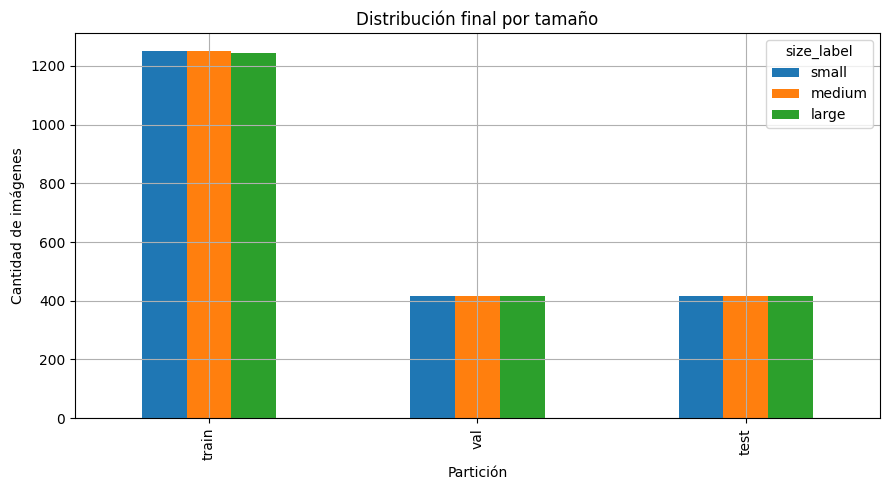

In [16]:
split_quality_table = pd.crosstab(df_export["split"], df_export["quality_label"]).reindex(index=["train", "val", "test"], columns=VALID_QUALITY_LABELS, fill_value=0)
split_size_table = pd.crosstab(df_export["split"], df_export["size_label"]).reindex(index=["train", "val", "test"], columns=VALID_SIZE_LABELS, fill_value=0)
split_product_table = pd.crosstab(df_export["split"], df_export["product_type"])
balanced_quality_table = train_balanced_export["quality_label"].value_counts().reindex(VALID_QUALITY_LABELS, fill_value=0).to_frame("train_balanced")

split_quality_table.to_csv(ANNOTATIONS_DIR / "split_quality_distribution.csv", encoding="utf-8")
split_size_table.to_csv(ANNOTATIONS_DIR / "split_size_distribution.csv", encoding="utf-8")
split_product_table.to_csv(ANNOTATIONS_DIR / "split_product_distribution.csv", encoding="utf-8")
balanced_quality_table.to_csv(ANNOTATIONS_DIR / "train_balanced_quality_distribution.csv", encoding="utf-8")

display(split_quality_table)
display(split_size_table)
display(balanced_quality_table)

ax = split_quality_table.plot(kind="bar")
ax.set_title("Distribución final por calidad")
ax.set_xlabel("Partición")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_split_quality_distribution.png", dpi=160)
plt.show()

ax = split_size_table.plot(kind="bar")
ax.set_title("Distribución final por tamaño")
ax.set_xlabel("Partición")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_split_size_distribution.png", dpi=160)
plt.show()


## 17. Función reutilizable de predicción de tamaño

Esta función sirve para probar una imagen individual. Si en la aplicación sabemos que la cámara está aproximadamente a un metro de la fruta, podemos enviar `distance_cm=100` y obtener una estimación aproximada del diámetro en centímetros. No es una medición perfecta: depende del campo de visión de la cámara y de que la fruta esté bien segmentada.


In [17]:
def predict_size_from_image_path(image_path, product_type="unknown", distance_cm=DEFAULT_OBJECT_DISTANCE_CM, camera_fov_degrees=DEFAULT_CAMERA_HORIZONTAL_FOV_DEGREES):
    path = build_image_path(image_path)
    features = estimate_size_features(path, product_type=product_type, distance_cm=distance_cm)
    payload = json.loads(SIZE_THRESHOLDS_PATH.read_text(encoding="utf-8"))
    product = normalize_product_name(product_type)
    cm_thresholds = None

    for key, value in payload.get("product_size_cm_thresholds", {}).items():
        if key in product:
            cm_thresholds = (value["small_medium_cm"], value["medium_large_cm"])
            break

    if cm_thresholds is not None and pd.notna(features["estimated_diameter_cm"]):
        size_label = label_from_thresholds(features["estimated_diameter_cm"], cm_thresholds)
        size_label_source = "estimated_cm"
    else:
        by_product = payload.get("by_product", {})
        selected = by_product.get(str(product_type).lower().strip(), payload.get("global"))
        if selected is None:
            size_label = "medium"
        else:
            size_label = label_from_thresholds(features["normalized_diameter"], (selected["q1"], selected["q2"]))
        size_label_source = "relative_threshold"

    return {
        "size_label": size_label,
        "size_label_es": SIZE_LABELS_ES[size_label],
        "size_label_source": size_label_source,
        "estimated_diameter_cm": features["estimated_diameter_cm"],
        "distance_cm": distance_cm,
        "normalized_diameter": features["normalized_diameter"],
        "object_area_ratio": features["object_area_ratio"],
        "skin_noise_ratio": features["skin_noise_ratio"],
        "segmentation_confidence": features["segmentation_confidence"],
        "review_reason": features["review_reason"]
    }


example_row = df_export.iloc[0]
predict_size_from_image_path(example_row["relative_path"], example_row["product_type"], distance_cm=100)


{'size_label': 'large',
 'size_label_es': 'grande',
 'size_label_source': 'estimated_cm',
 'estimated_diameter_cm': 104.3974426023938,
 'distance_cm': 100,
 'normalized_diameter': 0.9041083738380085,
 'object_area_ratio': 0.5767415364583334,
 'skin_noise_ratio': 0.13050672743055555,
 'segmentation_confidence': 0.7375252602743476,
 'review_reason': 'objeto_toca_borde'}

## 18. Muestra de imágenes procesadas

Revisamos visualmente que el guardado final esté correcto. Esta muestra también ayuda a encontrar casos en los que la etiqueta de tamaño o calidad todavía necesite una revisión manual.


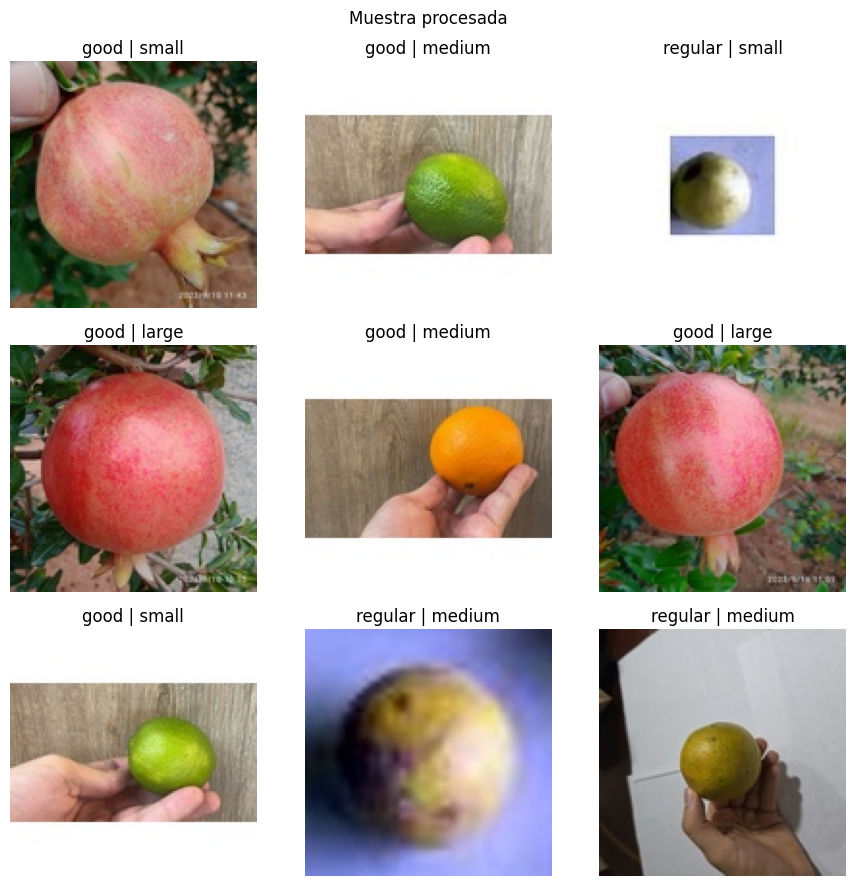

In [18]:
def show_processed_grid(data, title, n=9):
    if data.empty:
        print("No hay imágenes para visualizar.")
        return

    sample = data.sample(min(n, len(data)), random_state=RANDOM_STATE)
    cols = 3
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(cols * 3, rows * 3))

    for index, (_, row) in enumerate(sample.iterrows(), start=1):
        image_path = PROJECT_ROOT / row["processed_relative_path"]
        image = Image.open(image_path)
        plt.subplot(rows, cols, index)
        plt.imshow(image)
        plt.title(f"{row['quality_label']} | {row['size_label']}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "10_processed_sample.png", dpi=160)
    plt.show()


show_processed_grid(df_export, "Muestra procesada")


## 19. Resumen final

El cuaderno deja los datos listos para entrenar dos tareas: clasificación de calidad y clasificación o estimación aproximada de tamaño. También deja archivos de auditoría para justificar imágenes retiradas por ruido, duplicados, distribución final y balance del entrenamiento.


In [19]:
preprocessing_summary = pd.DataFrame({
    "metric": [
        "total_images_after_validation",
        "removed_invalid_images",
        "removed_duplicate_images",
        "flagged_review_images",
        "excluded_noise_images",
        "train_images",
        "train_balanced_images",
        "val_images",
        "test_images",
        "image_size",
        "quality_classes",
        "size_classes",
        "size_thresholds_path",
        "labels_processed_path",
        "train_path",
        "train_balanced_path",
        "val_path",
        "test_path",
        "processed_dir"
    ],
    "value": [
        len(df_export),
        len(invalid_df),
        len(duplicated_df),
        len(noisy_df),
        len(excluded_noise_df),
        len(train_export),
        len(train_balanced_export),
        len(val_export),
        len(test_export),
        f"{IMAGE_SIZE}x{IMAGE_SIZE}",
        ", ".join(VALID_QUALITY_LABELS),
        ", ".join(VALID_SIZE_LABELS),
        SIZE_THRESHOLDS_PATH.relative_to(PROJECT_ROOT).as_posix(),
        LABELS_PROCESSED_PATH.relative_to(PROJECT_ROOT).as_posix(),
        TRAIN_PATH.relative_to(PROJECT_ROOT).as_posix(),
        BALANCED_TRAIN_PATH.relative_to(PROJECT_ROOT).as_posix(),
        VAL_PATH.relative_to(PROJECT_ROOT).as_posix(),
        TEST_PATH.relative_to(PROJECT_ROOT).as_posix(),
        PROCESSED_DIR.relative_to(PROJECT_ROOT).as_posix()
    ]
})

preprocessing_summary.to_csv(PREPROCESSING_SUMMARY_PATH, index=False, encoding="utf-8")
display(preprocessing_summary)
print("Resumen guardado en:", PREPROCESSING_SUMMARY_PATH)


,metric,value
0,total_images_after_validation,6241
1,removed_invalid_images,0
2,removed_duplicate_images,33
3,flagged_review_images,7505
4,excluded_noise_images,2562
5,train_images,3744
6,train_balanced_images,1854
7,val_images,1248
8,test_images,1249
9,image_size,128x128


Resumen guardado en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\preprocessing_summary.csv
